# Catastro de Usos de la Tierra y Recursos Vegetacionales — análisis

Lee **exactamente lo que pinta el visor**: `frontend/public/datos/cbn_puntos.bin`
(1.827.933 centroides de polígono) más `manifest.json`, que es el contrato con los
offsets y los vocabularios.

El lector vive en [`ETL/leer_bin.py`](../ETL/leer_bin.py) y es la contraparte en Python
de `frontend/src/datos/binario.js`: mismo contrato, mismas validaciones, mismos
centinelas. Este notebook **no reimplementa la lectura** — si el ETL cambia el
vocabulario, aquí cambia solo.

> **Cada punto es el centroide de un polígono, no una parcela ni un predio.** Su posición
> representa al polígono completo; la superficie real está en `ha`. Y el Catastro **no es
> una serie temporal**: cada región se actualizó en un año distinto entre 2014 y 2024, así
> que compararlas entre sí compara fotos de años distintos (ver `region_anio`).

## 1 · Preparar el entorno

In [1]:
# Localiza la raiz del repo subiendo desde el cwd hasta encontrar ETL/leer_bin.py.
# Asi el notebook funciona lo mismo si lo abres desde notebooks/, desde la raiz o
# desde JupyterLab con otro directorio de trabajo.
import os, sys
from pathlib import Path

def raiz_repo(desde=None):
    p = Path(desde or os.getcwd()).resolve()
    for cand in (p, *p.parents):
        if (cand / "ETL" / "leer_bin.py").exists():
            return cand
    raise FileNotFoundError(
        "No encuentro la raiz del repo (ETL/leer_bin.py) subiendo desde " + str(p)
    )

RAIZ = raiz_repo()
sys.path.insert(0, str(RAIZ / "ETL"))
print("raiz del repo:", RAIZ)

raiz del repo: D:\GitHub\coipo_vista_catastro


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from leer_bin import cargar, leer_manifest, es, DATOS, CATEGORICOS

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

## 2 · Cargar

`cargar()` verifica el sha256 del `.bin` y que la suma de `ha` cuadre con el total que
publicó el ETL. Tarda unos segundos; pásale `verificar=False` mientras iteras.

In [3]:
man = leer_manifest()
df = cargar()          # verificar=False para saltarse sha256 y el cuadre

print(f"{es(len(df))} filas x {len(df.columns)} columnas")
print(f"{es(df.memory_usage(deep=True).sum() / 1e6, 1)} MB en memoria")
print(f"{es(df.ha.sum(), 2)} ha  (manifest: {es(man['total']['ha'], 2)})")

1.827.933 filas x 36 columnas
139,3 MB en memoria
75.661.200,50 ha  (manifest: 75.661.200,40)


## 3 · Anatomía de las columnas

Cada dimensión sale **dos veces**: `<campo>` con la etiqueta legible y `<campo>_cod` con
el código oficial. No es redundancia — las etiquetas se repiten entre códigos distintos
("Sin Información" está en varios subusos, "No Aplica" en varias estructuras), así que
**el único identificador unívoco es el código**. Agrupa por `_cod` siempre que la cifra
vaya a compararse con algo publicado.

In [4]:
resumen = pd.DataFrame(
    [
        {
            "columna": col,
            "dtype": str(df[col].dtype),
            "categorias": df[col].nunique() if str(df[col].dtype) == "category" else "",
            "sin dato": int(df[col].isna().sum()),
            "% sin dato": f"{100 * df[col].isna().mean():.1f}".replace(".", ","),
        }
        for col in df.columns
    ]
)
resumen

,columna,dtype,categorias,sin dato,% sin dato
0,lon,float32,,0,"0,0"
1,lat,float32,,0,"0,0"
2,ha,float64,,0,"0,0"
3,uso,category,9,0,"0,0"
4,uso_cod,category,9,0,"0,0"
5,uso_ipcc,category,7,0,"0,0"
6,subuso,category,37,0,"0,0"
7,subuso_cod,category,37,0,"0,0"
8,estruc,category,17,11262,"0,6"
9,estruc_cod,category,48,11262,"0,6"


In [5]:
df.head(5)[["lon", "lat", "ha", "uso", "subuso", "tifo", "especie_cientifico", "comuna", "region"]]

,lon,lat,ha,uso,subuso,tifo,especie_cientifico,comuna,region
0,-70.00,-21.44,1.40,Praderas y Matorrales,Matorral,No Aplica,Baccharis scandens,Iquique,Tarapacá
1,-69.99,-21.44,6.47,Praderas y Matorrales,Matorral,No Aplica,Baccharis scandens,Iquique,Tarapacá
2,-69.60,-21.57,146.64,Áreas Desprovistas de Vegetación,Otros sin Vegetación,No Aplica,NaN,Pozo Almonte,Tarapacá
3,-69.62,-21.53,"1,398.97",Áreas Desprovistas de Vegetación,Otros sin Vegetación,No Aplica,NaN,Pozo Almonte,Tarapacá
4,-69.75,-21.44,1.40,Áreas Desprovistas de Vegetación,Otros sin Vegetación,No Aplica,NaN,Pozo Almonte,Tarapacá


### Lo que significa cada bloque de columnas

| Columnas | Qué es | Vocabulario |
|---|---|---|
| `lon` `lat` | Centroide en EPSG:4326, `float32` (≈1 m). Sobra para agregar y mapear; **no** alcanza para trabajo predial | — |
| `ha` | Superficie del polígono. Promovida a `float64` al cargar | — |
| `uso` `uso_cod` `uso_ipcc` | Las 9 clases oficiales, más su equivalencia IPCC | guía oficial |
| `subuso` `estruc` | Subuso (43) y estructura (58) | guía oficial |
| `tifo` `stifo` `tifo_legal` | Tipo forestal (13) y subtipo (37). `tifo_legal` rotula solo lo citable: Alerce y Araucaria son Monumento Natural por decreto | guía / datos |
| `cober` `cober_orden` | Cobertura (Denso…Escaso). `cober_orden` permite ordenarla sin inventarse la escala | guía+datos |
| `altura` `altura_escala` `altura_desde` `altura_hasta` | **Ojo: son tres escalas distintas.** A–F mide Bosques, G–I mide Praderas y Matorrales, y J/K se solapan con ambas. Ponerlas en un solo eje ordenado sería falso — por eso está `altura_escala` | datos |
| `especie` `especie_cod` `especie_cientifico` `especie_genero` | Especie **principal** del polígono (989). El nombre común no sirve de clave: "eucalipto" son muchas | datos |
| `snaspe` `snaspe_cod` `snaspe_categoria` | Unidad del SNASPE (94). `NA` = **fuera** de área protegida, no "se desconoce" | datos |
| `comuna` `comuna_cod` `comuna_provincia` | 331 comunas | datos |
| `region` `region_cod` `region_anio` | Derivadas de la comuna. `region_anio` es **el año en que se actualizó esa región** | datos |

## 4 · La trampa que hay que tener presente en cada agregación

`groupby` de pandas **descarta los `NA` por defecto**. Como 79.731 filas no tienen comuna
—y por tanto tampoco región—, todo corte territorial pierde en silencio el 2,59 % de la
superficie nacional. La celda de abajo lo mide sobre el bosque nativo.

In [6]:
bn = df[df.subuso_cod == "0402"]          # Bosque Nativo

total    = bn.ha.sum()
agrupado = bn.groupby("region", observed=True).ha.sum().sum()
con_na   = bn.groupby("region", observed=True, dropna=False).ha.sum().sum()

print(f"bosque nativo, total                     {es(total, 2):>16}   <- cifra oficial")
print(f"  groupby('region').sum().sum()          {es(agrupado, 2):>16}   <- faltan {es(total - agrupado, 2)} ha")
print(f"  groupby('region', dropna=False)        {es(con_na, 2):>16}")
print()
sin_comuna = df[df.comuna.isna()]
print(f"a escala nacional, sin comuna: {es(sin_comuna.ha.sum(), 2)} ha "
      f"en {es(len(sin_comuna))} filas = {100 * sin_comuna.ha.sum() / df.ha.sum():.2f} % de la superficie")

bosque nativo, total                        15.536.329,01   <- cifra oficial
  groupby('region').sum().sum()             14.597.858,03   <- faltan 938.470,97 ha
  groupby('region', dropna=False)           15.536.329,01

a escala nacional, sin comuna: 1.962.476,04 ha en 79.731 filas = 2.59 % de la superficie


**Regla práctica:** usa `dropna=False` cuando el total tenga que cuadrar, o comprueba el
cuadre a mano. La función de abajo lo hace por ti y avisa si algo se perdió.

In [7]:
def agrupar(datos, por, valor="ha"):
    """groupby que NO pierde filas en silencio: conserva los NA y avisa cuanto pesan."""
    t = datos.groupby(por, observed=True, dropna=False)[valor].sum().sort_values(ascending=False)
    perdido = datos[valor].sum() - t.sum()
    if abs(perdido) > 0.01:
        print(f"AVISO: {es(perdido, 2)} {valor} fuera del agrupamiento")
    return t

agrupar(bn, "region").rename("ha").to_frame().head(20)

,ha
region,
Aysén,"5,152,384.32"
Los Lagos,"2,791,761.46"
Magallanes,"2,760,176.60"
La Araucanía,"1,043,078.86"
NaN,"938,470.97"
Biobío,"615,662.90"
Maule,"598,607.11"
O'Higgins,"428,775.88"
Valparaíso,"413,765.29"


## 5 · Ejemplos de análisis

In [8]:
# Superficie por uso, contrastada con la cifra que publico el ETL.
oficial = {u["cod"]: (u["etiqueta"], u["ha"]) for u in man["usos"]}
t = agrupar(df, "uso_cod").sort_index()

pd.DataFrame({
    "uso":       [oficial[k][0] for k in t.index],
    "ha":        t.values,
    "oficial":   [oficial[k][1] for k in t.index],
    "dif":       [t[k] - oficial[k][1] for k in t.index],
    "% del país": 100 * t.values / df.ha.sum(),
}, index=t.index)

,uso,ha,oficial,dif,% del país
uso_cod,,,,,
01,Áreas Urbanas e Industriales,"864,391.83","864,391.83",0.00,1.14
02,Terrenos Agrícolas,"4,088,178.65","4,088,178.65",0.00,5.40
03,Praderas y Matorrales,"29,282,364.33","29,282,364.32",0.01,38.70
04,Bosques,"18,862,754.85","18,862,754.85",0.00,24.93
05,Humedales,"831,088.25","831,088.25",0.00,1.10
06,Áreas Desprovistas de Vegetación,"17,191,344.49","17,191,344.39",0.10,22.72
07,Nieves Eternas y Glaciares,"2,756,878.66","2,756,878.68",-0.02,3.64
08,Cuerpos de Agua,"1,453,000.56","1,453,000.56",0.00,1.92
09,Áreas no Reconocidas,"331,198.86","331,198.86",0.00,0.44


In [9]:
# Plantaciones: las especies que concentran la superficie.
pl = df[df.subuso_cod == "0401"]
t = agrupar(pl, "especie_cientifico").head(12)

pd.DataFrame({
    "ha": t.values,
    "% de plantaciones": 100 * t.values / pl.ha.sum(),
    "polígonos": pl.groupby("especie_cientifico", observed=True).size().reindex(t.index).values,
}, index=t.index)

,ha,% de plantaciones,polígonos
especie_cientifico,,,
Pinus radiata,"1,714,737.31",54.56,116097
Eucalyptus globulus,"1,020,781.63",32.48,102112
Eucalyptus nitens,"202,547.58",6.44,14219
Acacia dealbata,"69,119.72",2.20,17330
Prosopis tamarugo,"28,874.64",0.92,2258
Pinus ponderosa,"25,188.41",0.80,1306
Pseudotsuga menziesii,"23,148.14",0.74,2357
Acacia saligna,"9,946.42",0.32,291
Salix babylonica,"8,352.50",0.27,1643


In [10]:
# Bosque nativo dentro y fuera del SNASPE, por region.
prot = (
    bn.assign(estado=np.where(bn.snaspe.notna(), "en SNASPE", "fuera"))
      .groupby(["region", "estado"], observed=True, dropna=False)
      .ha.sum().unstack(fill_value=0.0)
)
prot["total"] = prot.sum(axis=1)
prot["% protegido"] = 100 * prot["en SNASPE"] / prot["total"]
prot.sort_values("total", ascending=False)

estado,en SNASPE,fuera,total,% protegido
region,,,,
Aysén,"2,385,473.36","2,766,910.97","5,152,384.32",46.30
Los Lagos,"824,128.72","1,967,632.74","2,791,761.46",29.52
Magallanes,"1,246,458.21","1,513,718.39","2,760,176.60",45.16
La Araucanía,"156,606.28","886,472.58","1,043,078.86",15.01
NaN,"63,055.04","875,415.93","938,470.97",6.72
Biobío,"35,857.65","579,805.25","615,662.90",5.82
Maule,"2,785.59","595,821.52","598,607.11",0.47
O'Higgins,"5,818.30","422,957.57","428,775.88",1.36
Valparaíso,"8,670.80","405,094.48","413,765.29",2.10


In [11]:
# Tabla cruzada uso x region. observed=True evita materializar las combinaciones vacias.
cruce = pd.crosstab(
    df.region, df.uso, values=df.ha, aggfunc="sum", dropna=False
).fillna(0.0)
cruce.loc["TOTAL"] = cruce.sum()
cruce

uso,Áreas Urbanas e Industriales,Terrenos Agrícolas,Praderas y Matorrales,Bosques,Humedales,Áreas Desprovistas de Vegetación,Nieves Eternas y Glaciares,Cuerpos de Agua,Áreas no Reconocidas
region,,,,,,,,,
NaN,"12,068.75","336,483.89","144,398.80","1,163,546.38","11,288.28","52,324.57","5,340.66","109,855.82","127,168.89"
Tarapacá,"67,993.84","6,441.07","1,589,373.79","62,510.57","11,803.97","2,489,891.42",0.00,789.53,0.00
Antofagasta,"273,150.34","6,419.86","4,710,223.73","14,949.18","47,483.44","7,543,701.08",0.00,"10,036.44",0.00
Atacama,"46,177.80","37,486.35","5,262,601.43","3,500.58","8,919.38","2,196,833.77",0.00,"8,206.59",0.00
Coquimbo,"39,360.92","161,959.45","3,025,767.81","61,646.41","11,555.15","758,229.34",398.80,"2,709.82",0.00
Valparaíso,"72,055.47","189,062.67","679,982.65","491,551.42","2,853.24","139,179.26","17,155.78","5,695.85",0.00
O'Higgins,"41,138.95","396,377.50","363,947.92","590,238.65","3,594.27","185,398.84","35,994.12","17,772.71",0.00
Maule,"31,714.42","615,229.53","573,587.54","1,226,501.86","2,862.22","497,990.21","47,749.87","36,817.72",0.00
Biobío,"38,292.76","327,892.63","320,677.88","1,554,575.18","10,544.70","87,525.77","15,642.98","44,425.10",0.00


## 6 · Mapa

Los colores salen de `frontend/src/config.js`, no elegidos aquí: esa paleta se validó en
OKLab (separación para daltonismo y contraste) y volver a escogerla a ojo tiraría esa
validación a la basura. Se lee del archivo para que no pueda desincronizarse del visor.

> **Cómo leer este mapa.** Se pinta una clase encima de otra en orden de código, así que donde dos clases se solapan gana la última dibujada (09 sobre 08, sobre 07…). Sirve para ver la distribución de cada clase, **no** para leer proporciones en zonas mezcladas: para eso están las tablas de arriba. Es la misma razón por la que el visor deja aislar una clase al pulsarla.

In [12]:
import re

def paleta_del_visor(modo="claro"):
    """Extrae COLOR_USO[modo] de frontend/src/config.js. Falla ruidosamente si no
    encuentra las 9 clases: un mapa con la paleta a medias es peor que ninguno."""
    fuente = (RAIZ / "frontend" / "src" / "config.js").read_text(encoding="utf-8")
    bloque = re.search(rf"{modo}:\s*\{{(.*?)\}}", fuente, re.S)
    if not bloque:
        raise ValueError(f"no encuentro COLOR_USO.{modo} en config.js")
    colores = dict(re.findall(r"'(\d{2})':\s*'(#[0-9a-fA-F]{6})'", bloque.group(1)))
    if len(colores) != 9:
        raise ValueError(f"esperaba 9 clases y encontre {len(colores)}")
    return colores

PALETA = paleta_del_visor()
{c: PALETA[c] for c in sorted(PALETA)}

{'01': '#e34948',
 '02': '#eda100',
 '03': '#1baf7a',
 '04': '#008300',
 '05': '#4a3aa7',
 '06': '#eb6834',
 '07': '#2fb6dc',
 '08': '#2a78d6',
 '09': '#e87ba4'}

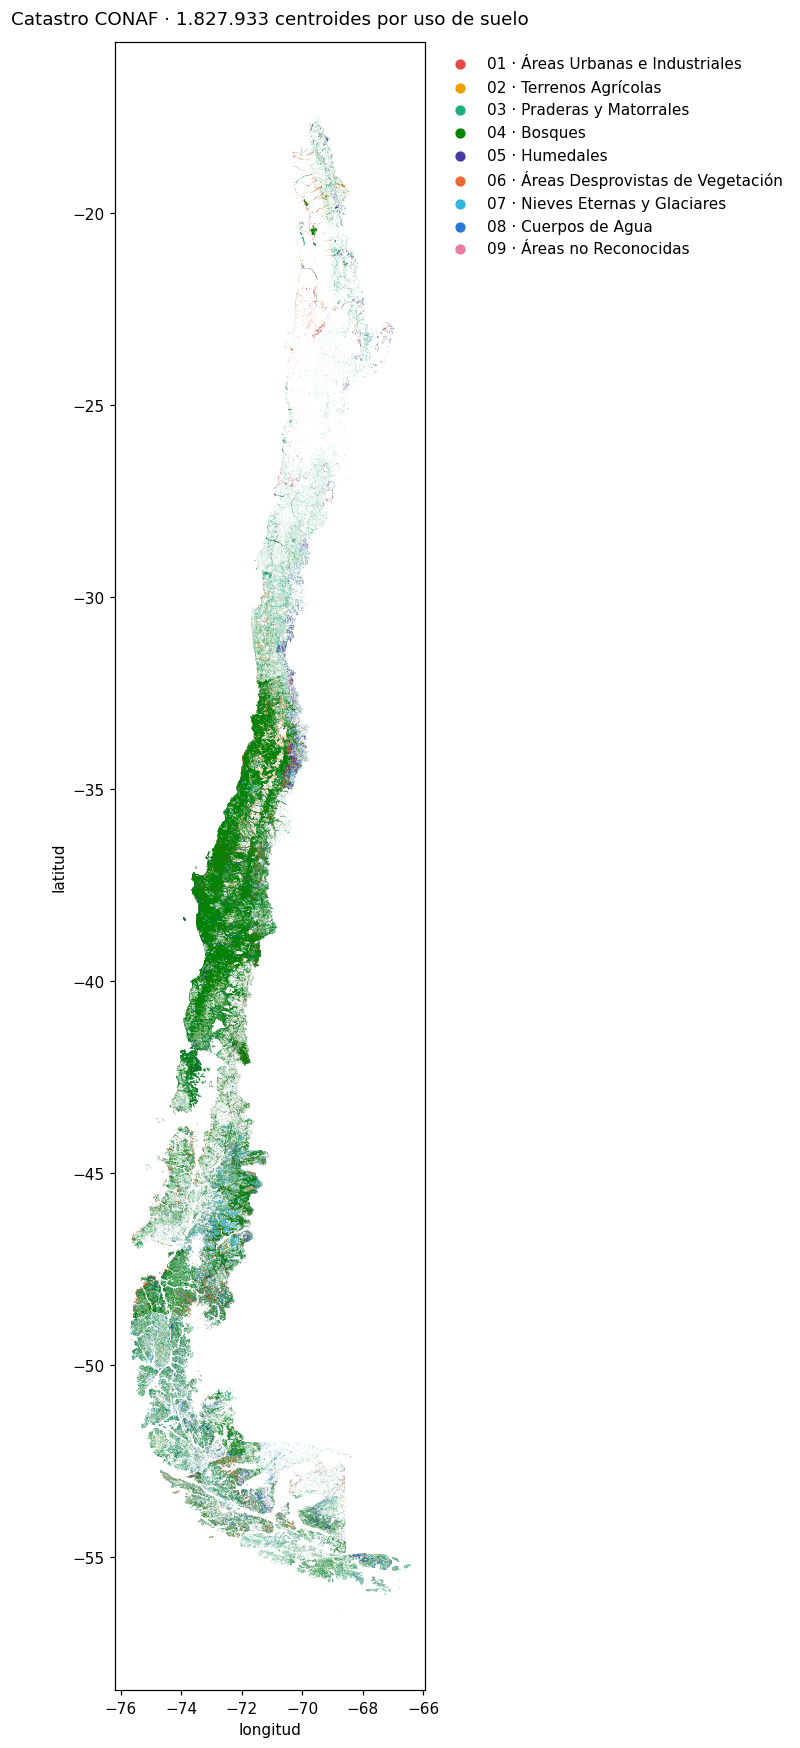

In [13]:
etiqueta = {u["cod"]: u["etiqueta"] for u in man["usos"]}

# Chile mide 4.300 km de norte a sur: la figura tiene que ser alta y estrecha o la
# franja se convierte en una linea.
fig, ax = plt.subplots(figsize=(6, 16), dpi=110)
for cod in sorted(PALETA):
    sel = df.uso_cod == cod
    ax.scatter(
        df.lon[sel], df.lat[sel],
        s=0.05, marker=".", linewidths=0, rasterized=True,
        c=PALETA[cod], label=f"{cod} · {etiqueta[cod]}",
    )

ax.set_aspect(1 / np.cos(np.radians(38)))   # Mercator simple a la latitud media de Chile
ax.set_xlabel("longitud"); ax.set_ylabel("latitud")
ax.set_title(f"Catastro CONAF · {es(len(df))} centroides por uso de suelo", pad=12)
leg = ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False, markerscale=60)
plt.tight_layout()
plt.show()

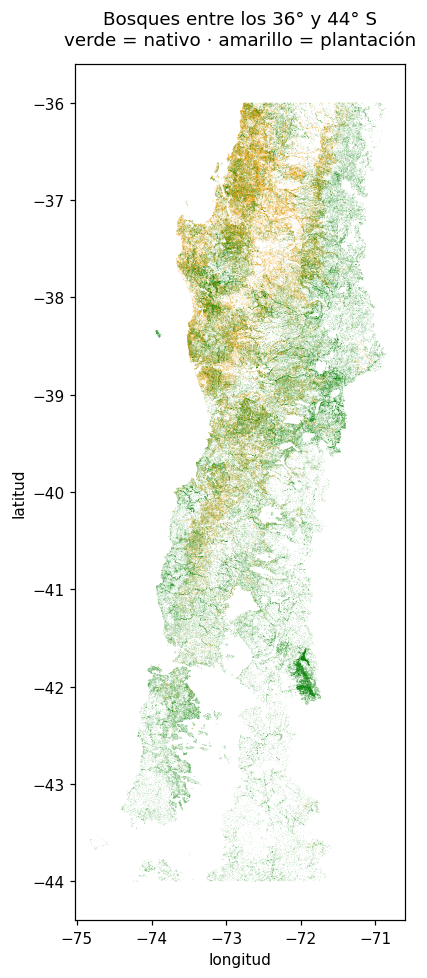

In [14]:
# Un recorte: solo Bosques, en la zona donde se concentran.
sur = df[(df.uso_cod == "04") & (df.lat.between(-44, -36))]

fig, ax = plt.subplots(figsize=(7, 9), dpi=110)
ax.scatter(sur.lon, sur.lat, s=0.15, marker=".", linewidths=0, rasterized=True,
           c=np.where(sur.subuso_cod == "0401", "#eda100", "#008300"))
ax.set_aspect(1 / np.cos(np.radians(40)))
ax.set_title("Bosques entre los 36° y 44° S\nverde = nativo · amarillo = plantación", pad=12)
ax.set_xlabel("longitud"); ax.set_ylabel("latitud")
plt.tight_layout()
plt.show()

## 7 · Exportar

Parquet conserva los tipos y las categóricas, pesa ~30 % del `.bin` y lo abren DuckDB,
polars, R y QGIS sin adaptador. Desde la terminal:

```
python ETL/leer_bin.py --parquet cbn.parquet
```

In [15]:
salida = RAIZ / "notebooks" / "cbn.parquet"
df.to_parquet(salida, index=False, compression="zstd")
print(f"{salida}  ({os.path.getsize(salida) / 1e6:,.1f} MB)")

D:\GitHub\coipo_vista_catastro\notebooks\cbn.parquet  (31.1 MB)


---

### Lo que este dataset **no** puede responder

- **No trae la geometría del polígono**, solo su centroide. Para superficies por
  intersección espacial (cuencas, predios, buffers) hace falta la capa original:
  `data/catastro_gef_singeometria.duckdb`, tabla `cbn_nacional_atributos`, que está en
  `.gitignore` y no viaja con el repo.
- **No es una serie temporal.** Ninguna comparación entre regiones es una comparación en
  el tiempo: mira `region_anio` antes de escribir cualquier conclusión sobre cambio.
- **`especie` es la especie principal** del polígono, no su composición.